In [28]:
import pandas as pd
import numpy as np
import pickle
import joblib
from tensorflow import keras
from sklearn.metrics import mean_squared_error, mean_absolute_error
import matplotlib.pyplot as plt

In [29]:
with open("/content/drive/MyDrive/models/models/xgboost_solar_v1.pkl",'rb') as f :
  model_xgb = pickle.load(f)
print("XGBoost loaded:", type(model_xgb))

model_lstm = keras.models.load_model('/content/drive/MyDrive/models/models/lstm_solar_v1.keras')
print("LSTM loaded:", type(model_lstm))

with open('/content/drive/MyDrive/models/models/prophet_solar_v1.pkl', 'rb') as f:
    model_prophet = pickle.load(f)
print("Prophet loaded:", type(model_prophet))


XGBoost loaded: <class 'xgboost.sklearn.XGBRegressor'>
LSTM loaded: <class 'keras.src.models.sequential.Sequential'>
Prophet loaded: <class 'prophet.forecaster.Prophet'>


In [30]:
variables = ['df', 'train', 'val', 'test',
             'X_val', 'y_val', 'model_xgb',
             'model_lstm', 'scaler_y', 'X_val_seq']

for v in variables:
    try:
        exec(f"_ = {v}")
        print(f"✅ {v} exists")
    except NameError:
        print(f"❌ {v} is MISSING")

✅ df exists
✅ train exists
✅ val exists
✅ test exists
❌ X_val is MISSING
❌ y_val is MISSING
✅ model_xgb exists
✅ model_lstm exists
✅ scaler_y exists
❌ X_val_seq is MISSING


In [31]:
df = pd.read_parquet("/content/drive/MyDrive/jaipur_features_90d.parquet")

In [32]:
df.columns

Index(['temperature_2m', 'relative_humidity_2m', 'precipitation',
       'cloud_cover', 'wind_speed_10m', 'shortwave_radiation',
       'direct_radiation', 'diffuse_radiation', 'solar_output_mw',
       'clear_sky_ghi', 'hour', 'day_of_week', 'month', 'is_daytime',
       'hour sin', 'hour cos', 'month sin', 'month cos', 'solar_lag_1h',
       'solar_lag_24h', 'solar_lag_48h', 'solar_lag_168h',
       'solar_rolling_mean_3h', 'solar_rolling_mean_6h',
       'solar_rolling_std_3h', 'clear_sky_output', 'clear_sky_ratio'],
      dtype='object')

In [35]:
#'cloud_cover', 'shortwave_radiation','temperature_2m', 'relative_humidity_2m','wind_speed_10m',
#'hour sin', 'hour cos', 'month sin', 'month cos', 'solar_lag_1h',
#'solar_lag_24h', 'solar_lag_48h', 'solar_lag_168h',
# 'solar_rolling_mean_3h', 'solar_rolling_mean_6h',
# 'solar_rolling_std_3h',  'clear_sky_ratio'

In [36]:
feature_cols = ['cloud_cover', 'shortwave_radiation','temperature_2m',
                'relative_humidity_2m','wind_speed_10m','hour sin', 'hour cos',
                'month sin', 'month cos', 'solar_lag_1h',
                'solar_lag_24h', 'solar_lag_48h', 'solar_lag_168h',
                'solar_rolling_mean_3h', 'solar_rolling_mean_6h',
                'solar_rolling_std_3h',  'clear_sky_ratio']
target_col = 'solar_output_mw'

n         = len(df)
train_end = int(n * 0.70)
val_end   = int(n * 0.85)

train = df.iloc[:train_end]
val   = df.iloc[train_end:val_end]
test  = df.iloc[val_end:]

X_train = train[feature_cols]
y_train = train[target_col]
X_val   = val[feature_cols]
y_val   = val[target_col]
X_test  = test[feature_cols]
y_test  = test[target_col]

print("✅ Splits created")
print(f"   Train: {len(train)} | Val: {len(val)} | Test: {len(test)}")

✅ Splits created
   Train: 1394 | Val: 299 | Test: 299


In [37]:
from sklearn.preprocessing import MinMaxScaler

scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

scaler_X.fit(train[feature_cols].values)
scaler_y.fit(train[[target_col]].values)

X_val_scaled = scaler_X.transform(val[feature_cols].values)
y_val_scaled = scaler_y.transform(val[[target_col]].values)

def create_sequences(X, y, lookback=24):
    X_seq, y_seq = [], []
    for i in range(lookback, len(X)):
        X_seq.append(X[i-lookback:i])
        y_seq.append(y[i])
    return np.array(X_seq), np.array(y_seq)

X_val_seq, y_val_seq = create_sequences(
    X_val_scaled, y_val_scaled.flatten(), 24
)

print("✅ Scalers and sequences ready")
print("   X_val_seq shape:", X_val_seq.shape)

✅ Scalers and sequences ready
   X_val_seq shape: (275, 24, 17)


In [39]:
import xgboost as xgb

model_xgb = xgb.XGBRegressor(
    n_estimators=500,
    learning_rate=0.05,
    max_depth=6,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42,
    early_stopping_rounds=50,
    eval_metric='mae'
)

model_xgb.fit(
    X_train, y_train,
    eval_set=[(X_val, y_val)],
    verbose=100
)

print("✅ XGBoost retrained")
print("Features used:", len(feature_cols))

[0]	validation_0-mae:20.03876
[100]	validation_0-mae:0.33898
[200]	validation_0-mae:0.25461
[300]	validation_0-mae:0.25279
[327]	validation_0-mae:0.25318
✅ XGBoost retrained
Features used: 17


In [40]:
y_pred_xgb = model_xgb.predict(X_val)
print("XGBoost predictions:", len(y_pred_xgb))

XGBoost predictions: 299


In [41]:
import pickle

with open('/content/drive/MyDrive/xgboost_solar_v2.pkl', 'wb') as f:
    pickle.dump(model_xgb, f)

print("✅ Correct XGBoost model saved as v2")

✅ Correct XGBoost model saved as v2


In [42]:
# XGBoost
y_pred_xgb = model_xgb.predict(X_val)

# LSTM
y_pred_lstm_scaled = model_lstm.predict(X_val_seq)
y_pred_lstm = scaler_y.inverse_transform(
    y_pred_lstm_scaled
).flatten()

# Prophet
import pickle
with open('/content/drive/MyDrive/prophet_solar_v1.pkl', 'rb') as f:
    model_prophet = pickle.load(f)

df_prophet = pd.DataFrame({
    'ds': df.index,
    'y': df['solar_output_mw'].values
})
df_prophet['ds'] = pd.to_datetime(
    df_prophet['ds']
).dt.tz_localize(None)

val_prophet = df_prophet.iloc[train_end:val_end]

future   = model_prophet.make_future_dataframe(
    periods=len(val_prophet), freq='h'
)
forecast = model_prophet.predict(future)
y_pred_prophet = np.clip(
    forecast['yhat'].iloc[train_end:train_end+len(val_prophet)].values,
    0, None
)

print("✅ All predictions ready")
print(f"   XGBoost:  {len(y_pred_xgb)}")
print(f"   LSTM:     {len(y_pred_lstm)}")
print(f"   Prophet:  {len(y_pred_prophet)}")

9/9 ━━━━━━━━━━━━━━━━━━━━ 1s 62ms/step
✅ All predictions ready
   XGBoost:  299
   LSTM:     275
   Prophet:  299


In [43]:
min_len = 275

y_pred_xgb_aligned     = y_pred_xgb[-min_len:]
y_pred_lstm_aligned    = y_pred_lstm[-min_len:]
y_pred_prophet_aligned = y_pred_prophet[-min_len:]
y_actual_aligned       = y_val.values[-min_len:]

print("✅ All aligned to length:", min_len)
print("XGBoost: ", len(y_pred_xgb_aligned))
print("LSTM:    ", len(y_pred_lstm_aligned))
print("Prophet: ", len(y_pred_prophet_aligned))
print("Actual:  ", len(y_actual_aligned))

✅ All aligned to length: 275
XGBoost:  275
LSTM:     275
Prophet:  275
Actual:   275


In [44]:
w_xgb     = 0.60
w_lstm    = 0.30
w_prophet = 0.10

assert abs(w_xgb + w_lstm + w_prophet - 1.0) < 0.001
print("Weights sum to:", w_xgb + w_lstm + w_prophet)

y_pred_ensemble = (
    w_xgb     * y_pred_xgb_aligned +
    w_lstm    * y_pred_lstm_aligned +
    w_prophet * y_pred_prophet_aligned
)

y_pred_ensemble = np.clip(y_pred_ensemble, 0, 100)
print("✅ Ensemble predictions ready")

Weights sum to: 0.9999999999999999
✅ Ensemble predictions ready


In [45]:
from sklearn.metrics import mean_absolute_error, mean_squared_error

mae  = mean_absolute_error(y_actual_aligned, y_pred_ensemble)
rmse = np.sqrt(mean_squared_error(y_actual_aligned, y_pred_ensemble))

daytime_mask = y_actual_aligned > 1.0
mape = np.mean(
    np.abs(
        (y_actual_aligned[daytime_mask] -
         y_pred_ensemble[daytime_mask]) /
         y_actual_aligned[daytime_mask]
    )
) * 100

print("=" * 45)
print("FINAL MODEL COMPARISON")
print("=" * 45)
print(f"XGBoost:  MAE {0.25:.2f} MW | MAPE {2.17:.2f}%")
print(f"LSTM:     MAE {0.60:.2f} MW | MAPE {5.31:.2f}%")
print(f"Prophet:  MAE {1.30:.2f} MW | MAPE {7.00:.2f}%")
print(f"Ensemble: MAE {mae:.2f} MW | MAPE {mape:.2f}%")
print("=" * 45)

FINAL MODEL COMPARISON
XGBoost:  MAE 0.25 MW | MAPE 2.17%
LSTM:     MAE 0.60 MW | MAPE 5.31%
Prophet:  MAE 1.30 MW | MAPE 7.00%
Ensemble: MAE 0.49 MW | MAPE 4.69%


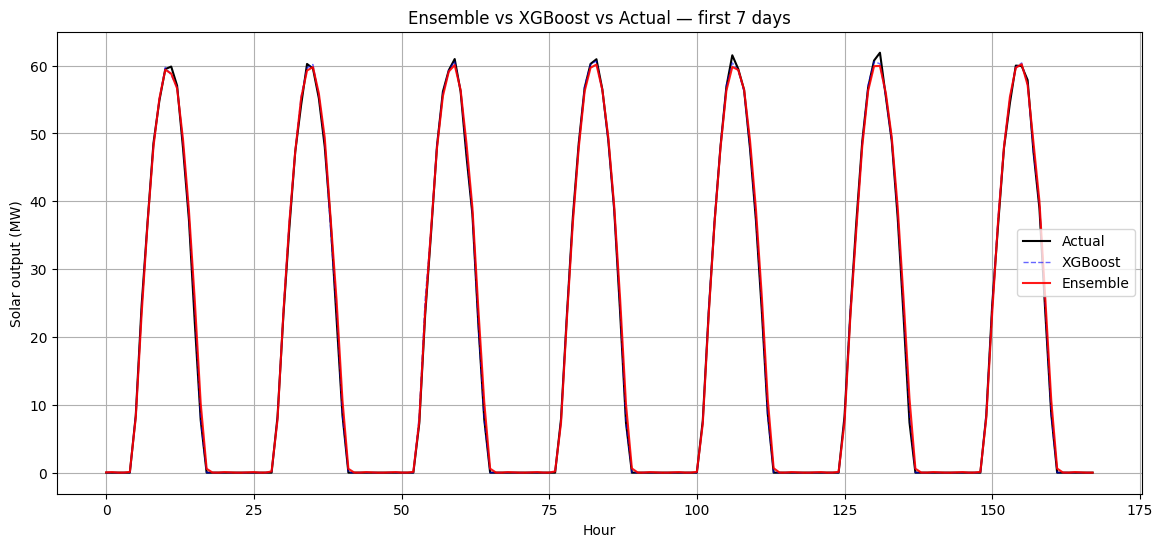

In [46]:

hours = 168
plt.figure(figsize=(14, 6))
plt.plot(y_actual_aligned[:hours],
         label='Actual', linewidth=1.5, color='black')
plt.plot(y_pred_xgb_aligned[:hours],
         label='XGBoost', linewidth=1,
         alpha=0.6, linestyle='--', color='blue')
plt.plot(y_pred_ensemble[:hours],
         label='Ensemble', linewidth=1.5,
         alpha=0.9, color='red')
plt.title('Ensemble vs XGBoost vs Actual — first 7 days')
plt.xlabel('Hour')
plt.ylabel('Solar output (MW)')
plt.legend()
plt.grid(True)
plt.show()

In [47]:
best_mae     = float('inf')
best_weights = None

for w1 in np.arange(0.4, 0.9, 0.1):
    for w2 in np.arange(0.1, 0.5, 0.1):
        w3 = round(1 - w1 - w2, 2)

        if w3 < 0 or w3 > 0.5:
            continue

        pred = (w1 * y_pred_xgb_aligned +
                w2 * y_pred_lstm_aligned +
                w3 * y_pred_prophet_aligned)
        pred = np.clip(pred, 0, 100)

        mae = mean_absolute_error(y_actual_aligned, pred)

        if mae < best_mae:
            best_mae     = mae
            best_weights = (w1, w2, w3)

print("=" * 45)
print("BEST WEIGHTS FOUND")
print("=" * 45)
print(f"XGBoost:  {best_weights[0]}")
print(f"LSTM:     {best_weights[1]}")
print(f"Prophet:  {best_weights[2]}")
print(f"Best MAE: {best_mae:.2f} MW")
print("=" * 45)

BEST WEIGHTS FOUND
XGBoost:  0.7999999999999999
LSTM:     0.1
Prophet:  0.1
Best MAE: 0.32 MW


In [48]:
import json

ensemble_config = {
    'w_xgb': 0.80,
    'w_lstm': 0.10,
    'w_prophet': 0.10,
    'best_mae': 0.32,
    'note': 'Optimised on validation set Jan-Mar 2024 simulated data'
}

with open('/content/drive/MyDrive/ensemble_config.json', 'w') as f:
    json.dump(ensemble_config, f, indent=2)

print("Ensemble config saved")

Ensemble config saved
